Section 1: Data Understanding

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error



In [2]:
import pandas as pd
df=pd.read_csv("D:\python\practice\data\Salary Data.csv")
df.head()

<>:2: SyntaxWarning: invalid escape sequence '\p'
<>:2: SyntaxWarning: invalid escape sequence '\p'
C:\Users\atasn\AppData\Local\Temp\ipykernel_5260\2051605969.py:2: SyntaxWarning: invalid escape sequence '\p'
  df=pd.read_csv("D:\python\practice\data\Salary Data.csv")


,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [4]:
#1. How many rows and columns are present in the dataset?
print(df.shape)

#2. Which columns have missing values, and how many missing values are there in each?
print(df.isnull().sum())

#3. Identify the categorical and numerical columns in the dataset.
df.dtypes

(375, 6)
Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64


Age                    float64
Gender                     str
Education Level            str
Job Title                  str
Years of Experience    float64
Salary                 float64
dtype: object

In [5]:
#4. Calculate the mean, median, and standard deviation of the Age column.
df['Age'].mean()
df['Age'].median()
df['Age'].std()

np.float64(7.069072938567494)

In [8]:
#5. Which gender has a higher proportion in the dataset? Provide percentages.
print(df['Gender'].value_counts(normalize=True) * 100)

#6. List the unique education levels and their proportion in the dataset.
print(df['Education Level'].value_counts(normalize=True) * 100)

Gender
Male      52.010724
Female    47.989276
Name: proportion, dtype: float64
Education Level
Bachelor's    60.053619
Master's      26.273458
PhD           13.672922
Name: proportion, dtype: float64


Section 2: Data Cleaning & Preprocessing

In [11]:
#7. How many rows contain all NaN values? How would you handle these rows?
print(df.isnull().all(axis=1).sum())
print(df.dropna(how='all', inplace=True))
print(df.dropna(inplace=True))

0
None
None


In [ ]:
#8. How many duplicate rows are present in the dataset? 

df.duplicated().sum()

np.int64(49)

In [12]:
#9. Why is it important to reset the index after removing duplicates and NaN rows?
df.reset_index(drop=True, inplace=True)

In [14]:
#10. Explain why we need to encode categorical variables before building a predictive model.
df2 = pd.get_dummies(df, drop_first=True)

Section 3: Exploratory Data Analysis (EDA)

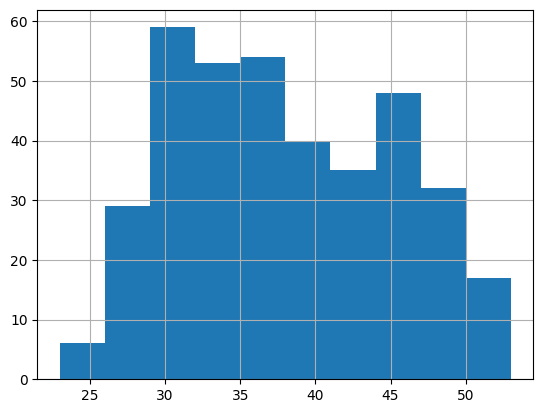

In [16]:
#11. Plot the distribution of Age. Comment on its skewness.
import matplotlib.pyplot as plt
df['Age'].hist()
plt.show()

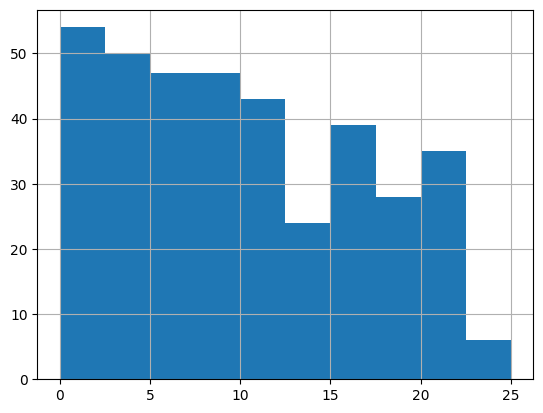

In [17]:
#12. Plot the distribution of Years of Experience. What can you infer about the experience levels of employees?
df['Years of Experience'].hist()
plt.show()

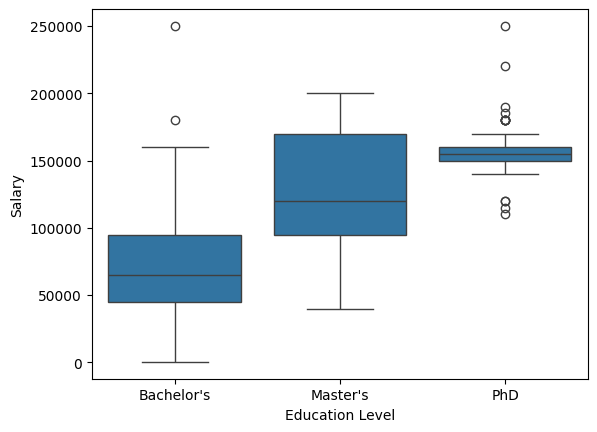

In [20]:
#13. Plot a boxplot of Salary vs Education Level. What insights can you derive from this visualization?
import seaborn as sns
sns.boxplot(x='Education Level', y='Salary', data=df)
plt.show()

In [21]:
#14. Calculate the average salary by gender. Which gender earns more on average?
df.groupby('Gender')['Salary'].mean()

Gender
Female     97011.173184
Male      103867.783505
Name: Salary, dtype: float64

In [22]:
#15. How does education level influence the average salary?
df.groupby('Education Level')['Salary'].mean()

Education Level
Bachelor's     74756.026786
Master's      129795.918367
PhD           157843.137255
Name: Salary, dtype: float64

In [23]:
#16. How do years of experience influence salary? Divide experience into 5 categories:
bins = [0,5,10,15,20,100]
labels = ['0-5','6-10','11-15','16-20','20+'] # 0–5 years, 6–10 years, 11–15 years, 16–20 years, 20+ years

df['Exp Category'] = pd.cut(df['Years of Experience'], bins=bins, labels=labels)

df.groupby('Exp Category')['Salary'].mean()

Exp Category
0-5       49367.372881
6-10      92578.947368
11-15    118230.769231
16-20    159140.625000
20+      175892.857143
Name: Salary, dtype: float64

Section 4: Correlation & Relationships

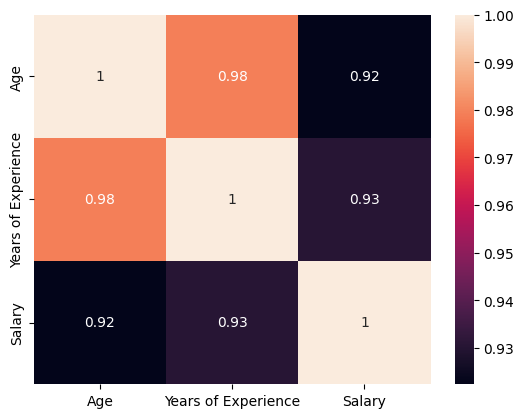

In [25]:
#17. Create a correlation heatmap of numerical columns. Which features are strongly correlated with Salary?
import numpy as np
num_cols =df.select_dtypes(include=np.number)

sns.heatmap(num_cols.corr(), annot=True)
plt.show()

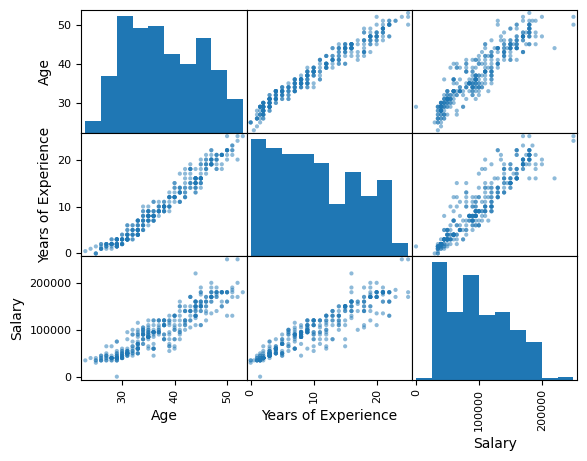

In [26]:
#18. Create a scatter matrix for numerical variables. Which relationships appear linear?
pd.plotting.scatter_matrix(df)
plt.show()

Section 5: Model Building

In [27]:
#19. Which columns are selected as features (X) and which as the target (y) for prediction?
X = df.drop('Salary', axis=1)
y = df['Salary']

In [30]:
#20. What is the purpose of splitting the dataset into training and testing sets?
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [31]:
#21. What algorithm is used for prediction? Why is it suitable for this problem?

model = LinearRegression()

In [41]:
#22. After fitting the model, what is the training score?

df.fillna(df.select_dtypes(include=['number']).mean(), inplace=True)
df.dropna(inplace=True)

df = pd.get_dummies(df, drop_first=True)
X = df.drop("Salary", axis=1)
y = df["Salary"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = LinearRegression()
model.fit(X_train, y_train)
model.score(X_train, y_train)

0.9875117660238054

In [40]:
#23. Predict the salary for the test dataset and calculate the R² score. What does it indicate about the model?
from sklearn.metrics import r2_score
y_pred = model.predict(X_test)
r2_score(y_test, y_pred)

0.7447783396025403

In [43]:
#24. Calculate the RMSE (Root Mean Squared Error) for predictions. What does this value tell you about prediction accuracy?
from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
rmse

np.float64(62561.76837835978)

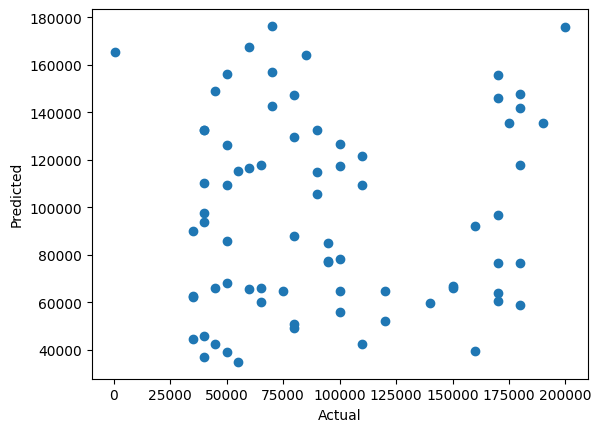

In [44]:
#25. Plot predicted vs actual salaries. What insights can you derive from this plot?
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()